# 🎯 YOLO + FaceNet — End-to-End Pipeline Evaluation on LFW

Evaluates the **full attendance pipeline** on the LFW public dataset:

```
LFW image  →  YOLO (face detect)  →  crop  →  FaceNet + FAISS  →  result
```

**Metrics reported:**
- YOLO Stage: Detection Rate, Miss Rate, Avg Confidence
- Full Pipeline: Accuracy, Precision, Recall, F1, Specificity, AUC-ROC, EER, FAR, FRR

**Dataset split (per person, persons with ≥ MIN_IMAGES):**
- 70% train → build FAISS gallery
- 10% val   → tune similarity threshold
- 20% test  → final evaluation

## 1. Imports

In [1]:
import sys, os
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

import pickle, random, math
from pathlib import Path
from collections import defaultdict

import numpy as np
import cv2
import torch
from ultralytics import YOLO
from facenet_pytorch import InceptionResnetV1, MTCNN
import faiss
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, average_precision_score, precision_recall_curve,
    confusion_matrix, r2_score, classification_report
)

print("✅ All imports successful")

✅ All imports successful


## 2. Configuration

Adjust the parameters below before running the notebook.

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
ROOT             = Path(".")   # directory containing this notebook
LFW_DATASET_ROOT = ROOT / "lfw_dataset"
_candidates      = [
    LFW_DATASET_ROOT / "lfw",
    LFW_DATASET_ROOT / "lfw-deepfunneled" / "lfw-deepfunneled",
    LFW_DATASET_ROOT / "lfw-deepfunneled",
]
LFW_DIR          = next((p for p in _candidates if p.exists()),
                        LFW_DATASET_ROOT / "lfw")
YOLO_WEIGHTS     = ROOT / "yolov8n.pt"
CACHE_FILE       = LFW_DATASET_ROOT / "pipeline_embeddings_cache.pkl"
RESULTS_DIR      = ROOT / "eval_results"

# ── Hyperparameters ────────────────────────────────────────────────────────
MIN_IMAGES     = 5       # Only persons with at least this many images
RANDOM_SEED    = 42
TRAIN_RATIO    = 0.70
VAL_RATIO      = 0.10
TEST_RATIO     = 0.20
IMG_SIZE       = 160     # FaceNet input resolution
YOLO_CONF      = 0.35    # YOLO confidence threshold for face detection
UPSCALE_TARGET = 160     # Minimum face crop size before FaceNet

print(f"LFW directory : {LFW_DIR}")
print(f"YOLO weights  : {YOLO_WEIGHTS}")
print(f"LFW exists    : {LFW_DIR.exists()}")
print(f"YOLO exists   : {YOLO_WEIGHTS.exists()}")

LFW directory : lfw_dataset\lfw-deepfunneled\lfw-deepfunneled
YOLO weights  : yolov8n.pt
LFW exists    : True
YOLO exists   : True


## 3. Dataset Preparation

Collect persons from LFW and split into train / val / test.

In [3]:
def collect_persons(min_images: int):
    persons = defaultdict(list)
    for d in sorted(LFW_DIR.iterdir()):
        if not d.is_dir():
            continue
        imgs = sorted(d.glob("*.jpg"))
        if len(imgs) >= min_images:
            persons[d.name] = [str(p) for p in imgs]
    total = sum(len(v) for v in persons.values())
    print(f"Found {len(persons)} persons with >= {min_images} images ({total} images total)")
    return persons


def split_dataset(persons: dict):
    random.seed(RANDOM_SEED)
    train, val, test = {}, {}, {}
    for name, imgs in persons.items():
        random.shuffle(imgs)
        n    = len(imgs)
        n_tr = max(1, math.floor(n * TRAIN_RATIO))
        n_va = max(1, math.floor(n * VAL_RATIO))
        train[name] = imgs[:n_tr]
        val[name]   = imgs[n_tr:n_tr + n_va]
        test[name]  = imgs[n_tr + n_va:]
    n_tr = sum(len(v) for v in train.values())
    n_va = sum(len(v) for v in val.values())
    n_te = sum(len(v) for v in test.values())
    tot  = n_tr + n_va + n_te
    print(f"\nSplit → train={n_tr} ({100*n_tr//tot}%) | val={n_va} ({100*n_va//tot}%) | test={n_te} ({100*n_te//tot}%)")
    return train, val, test


persons = collect_persons(MIN_IMAGES)
train, val, test = split_dataset(persons)

Found 423 persons with >= 5 images (5985 images total)

Split → train=3992 (66%) | val=642 (10%) | test=1351 (22%)


## 4. Load Models (YOLO + FaceNet + MTCNN)

In [4]:
def load_models(yolo_conf: float):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    yolo    = YOLO(str(YOLO_WEIGHTS))
    facenet = InceptionResnetV1(pretrained="vggface2").eval().to(device)
    mtcnn   = MTCNN(image_size=IMG_SIZE, margin=0, keep_all=False, device=device)
    return yolo, facenet, mtcnn, device, yolo_conf


yolo, facenet, mtcnn, device, yolo_conf = load_models(YOLO_CONF)
print("✅ Models loaded")

Device: cpu
✅ Models loaded


## 5. Full Pipeline: YOLO → Crop → FaceNet Embedding

In [5]:
def upscale_face(face_bgr: np.ndarray, target: int = UPSCALE_TARGET) -> np.ndarray:
    """Upscale small face crops and apply CLAHE for contrast enhancement."""
    if face_bgr is None or face_bgr.size == 0:
        return face_bgr
    h, w = face_bgr.shape[:2]
    if min(h, w) < target:
        scale = target / min(h, w)
        face_bgr = cv2.resize(face_bgr, (int(w*scale), int(h*scale)),
                              interpolation=cv2.INTER_CUBIC)
    lab = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(2.0, (4, 4)).apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)


def get_embedding_via_pipeline(img_path: str, yolo, facenet, mtcnn, device, yolo_conf: float):
    """
    Full pipeline: YOLO detect → crop → upscale → FaceNet embed.
    Returns (embedding, detected: bool)
    """
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None, False

    # YOLO detection — person class
    results  = yolo(img_bgr, verbose=False, classes=[0])
    boxes    = results[0].boxes
    face_crop = None

    if boxes is not None and len(boxes) > 0:
        confs = boxes.conf.cpu().numpy()
        best  = int(np.argmax(confs))
        if float(confs[best]) >= yolo_conf:
            x1, y1, x2, y2 = boxes.xyxy[best].cpu().numpy().astype(int)
            H, W = img_bgr.shape[:2]
            mg   = max(4, int(min(x2-x1, y2-y1)*0.08))
            face_crop = img_bgr[max(0,y1-mg):min(H,y2+mg),
                                max(0,x1-mg):min(W,x2+mg)]

    detected = face_crop is not None and face_crop.size > 0

    # Fallback: use whole image (LFW images are already cropped)
    if not detected:
        face_crop = img_bgr

    face_up  = upscale_face(face_crop)
    face_rgb = cv2.cvtColor(face_up, cv2.COLOR_BGR2RGB)

    # MTCNN alignment
    try:
        aligned = mtcnn(face_rgb)
        if aligned is None:
            raise ValueError
        tensor = aligned
    except Exception:
        r      = cv2.resize(face_rgb, (IMG_SIZE, IMG_SIZE))
        tensor = torch.from_numpy(r).permute(2, 0, 1).float()
        tensor = (tensor - 127.5) / 128.0

    tensor = tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        emb = facenet(tensor).cpu().numpy().flatten()
    emb = (emb / (np.linalg.norm(emb) + 1e-8)).astype("float32")
    return emb, detected


def extract_all_pipeline(split_dict: dict, yolo, facenet, mtcnn, device, yolo_conf: float, desc=""):
    result = {}
    detect_count = {True: 0, False: 0}
    total = sum(len(v) for v in split_dict.values())
    done  = 0
    for name, imgs in split_dict.items():
        embs = []
        for img_path in imgs:
            emb, det = get_embedding_via_pipeline(img_path, yolo, facenet, mtcnn, device, yolo_conf)
            if emb is not None:
                embs.append(emb)
            detect_count[det] += 1
            done += 1
            if done % 200 == 0:
                dr = detect_count[True] / (done + 1e-6) * 100
                print(f"  {desc}: {done}/{total} | YOLO det rate: {dr:.1f}%")
        if embs:
            result[name] = embs
    dr = detect_count[True] / (detect_count[True] + detect_count[False] + 1e-6)
    print(f"  {desc} YOLO Detection Rate: {dr*100:.2f}%  "
          f"({detect_count[True]} detected, {detect_count[False]} missed)")
    return result, dr


print("✅ Pipeline functions defined")

✅ Pipeline functions defined


## 6. Extract Embeddings (with Cache)

> ⏱️ **This is the slowest step.** On CPU it may take 30–60 min for the full LFW dataset.  
> Results are cached to `pipeline_embeddings_cache.pkl` so subsequent runs are instant.

In [6]:
def build_cache(train, val, test, yolo, facenet, mtcnn, device, yolo_conf):
    if CACHE_FILE.exists():
        print("Loading pipeline embeddings from cache ...")
        with open(CACHE_FILE, "rb") as f:
            return pickle.load(f)
    print("\nExtracting embeddings through full pipeline (YOLO → FaceNet) ...")
    train_embs, dr_tr = extract_all_pipeline(train, yolo, facenet, mtcnn, device, yolo_conf, "train")
    val_embs,   dr_va = extract_all_pipeline(val,   yolo, facenet, mtcnn, device, yolo_conf, "val")
    test_embs,  dr_te = extract_all_pipeline(test,  yolo, facenet, mtcnn, device, yolo_conf, "test")
    data = {
        "train": train_embs, "val": val_embs, "test": test_embs,
        "yolo_det_rate": {"train": dr_tr, "val": dr_va, "test": dr_te},
    }
    CACHE_FILE.parent.mkdir(parents=True, exist_ok=True)
    with open(CACHE_FILE, "wb") as f:
        pickle.dump(data, f)
    print("Pipeline embeddings cached.")
    return data


cache = build_cache(train, val, test, yolo, facenet, mtcnn, device, yolo_conf)
print("\n✅ Embeddings ready")

Loading pipeline embeddings from cache ...



✅ Embeddings ready


## 7. Build FAISS Gallery

In [7]:
def build_gallery(train_embs: dict):
    """Compute per-person mean embedding and index them in FAISS."""
    names, vecs = [], []
    for name, emb_list in train_embs.items():
        mean_emb = np.mean(emb_list, axis=0).astype("float32")
        mean_emb /= (np.linalg.norm(mean_emb) + 1e-8)
        names.append(name)
        vecs.append(mean_emb)
    matrix = np.vstack(vecs)
    faiss.normalize_L2(matrix)
    index  = faiss.IndexFlatIP(matrix.shape[1])
    index.add(matrix)
    return index, names


print("Building FAISS gallery from train embeddings ...")
gallery_index, gallery_names = build_gallery(cache["train"])
print(f"✅ Gallery built: {len(gallery_names)} persons indexed")

Building FAISS gallery from train embeddings ...
✅ Gallery built: 423 persons indexed


## 8. Threshold Tuning on Validation Set

In [8]:
def evaluate_split(embs_dict: dict, gallery_index, gallery_names: list, threshold: float):
    y_true, y_pred, scores = [], [], []
    for true_name, emb_list in embs_dict.items():
        for emb in emb_list:
            q = np.array([emb], dtype="float32")
            faiss.normalize_L2(q)
            D, I      = gallery_index.search(q, k=1)
            sim       = float(D[0][0])
            pred_name = gallery_names[int(I[0][0])]
            y_true.append(int(pred_name == true_name))
            y_pred.append(int(sim >= threshold))
            scores.append(sim)
    return np.array(y_true), np.array(y_pred), np.array(scores)


def find_optimal_threshold(val_embs: dict, gallery_index, gallery_names: list):
    """Sweep thresholds and return the one maximising F1 on the val set."""
    truths, all_scores = [], []
    for true_name, emb_list in val_embs.items():
        for emb in emb_list:
            q = np.array([emb], dtype="float32")
            faiss.normalize_L2(q)
            D, I      = gallery_index.search(q, k=1)
            pred_name = gallery_names[int(I[0][0])]
            truths.append(int(pred_name == true_name))
            all_scores.append(float(D[0][0]))
    truths     = np.array(truths)
    scores_arr = np.array(all_scores)
    best_f1, best_thr = 0.0, 0.5
    for thr in np.arange(0.1, 0.95, 0.01):
        preds = (scores_arr >= thr).astype(int)
        if preds.sum() == 0:
            continue
        f = f1_score(truths, preds, zero_division=0)
        if f > best_f1:
            best_f1, best_thr = f, thr
    print(f"  Optimal threshold (val F1={best_f1:.4f}): {best_thr:.3f}")
    return best_thr


print("Finding optimal threshold on validation set ...")
threshold = find_optimal_threshold(cache["val"], gallery_index, gallery_names)

Finding optimal threshold on validation set ...
  Optimal threshold (val F1=0.9885): 0.530


## 9. Evaluate on Test Set

In [9]:
print(f"Evaluating on test set (threshold={threshold:.3f}) ...")
y_true, y_pred, scores = evaluate_split(
    cache["test"], gallery_index, gallery_names, threshold
)

print("\n" + "=" * 50)
print("  RESULTS — YOLO + FaceNet Pipeline")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=["Mismatch", "Match"]))

Evaluating on test set (threshold=0.530) ...

  RESULTS — YOLO + FaceNet Pipeline
              precision    recall  f1-score   support

    Mismatch       0.92      0.59      0.72        92
       Match       0.97      1.00      0.98      1259

    accuracy                           0.97      1351
   macro avg       0.94      0.79      0.85      1351
weighted avg       0.97      0.97      0.96      1351



## 10. Visualise Results — Full Dashboard


📊 Dashboard saved: eval_results\pipeline_lfw_dashboard.png


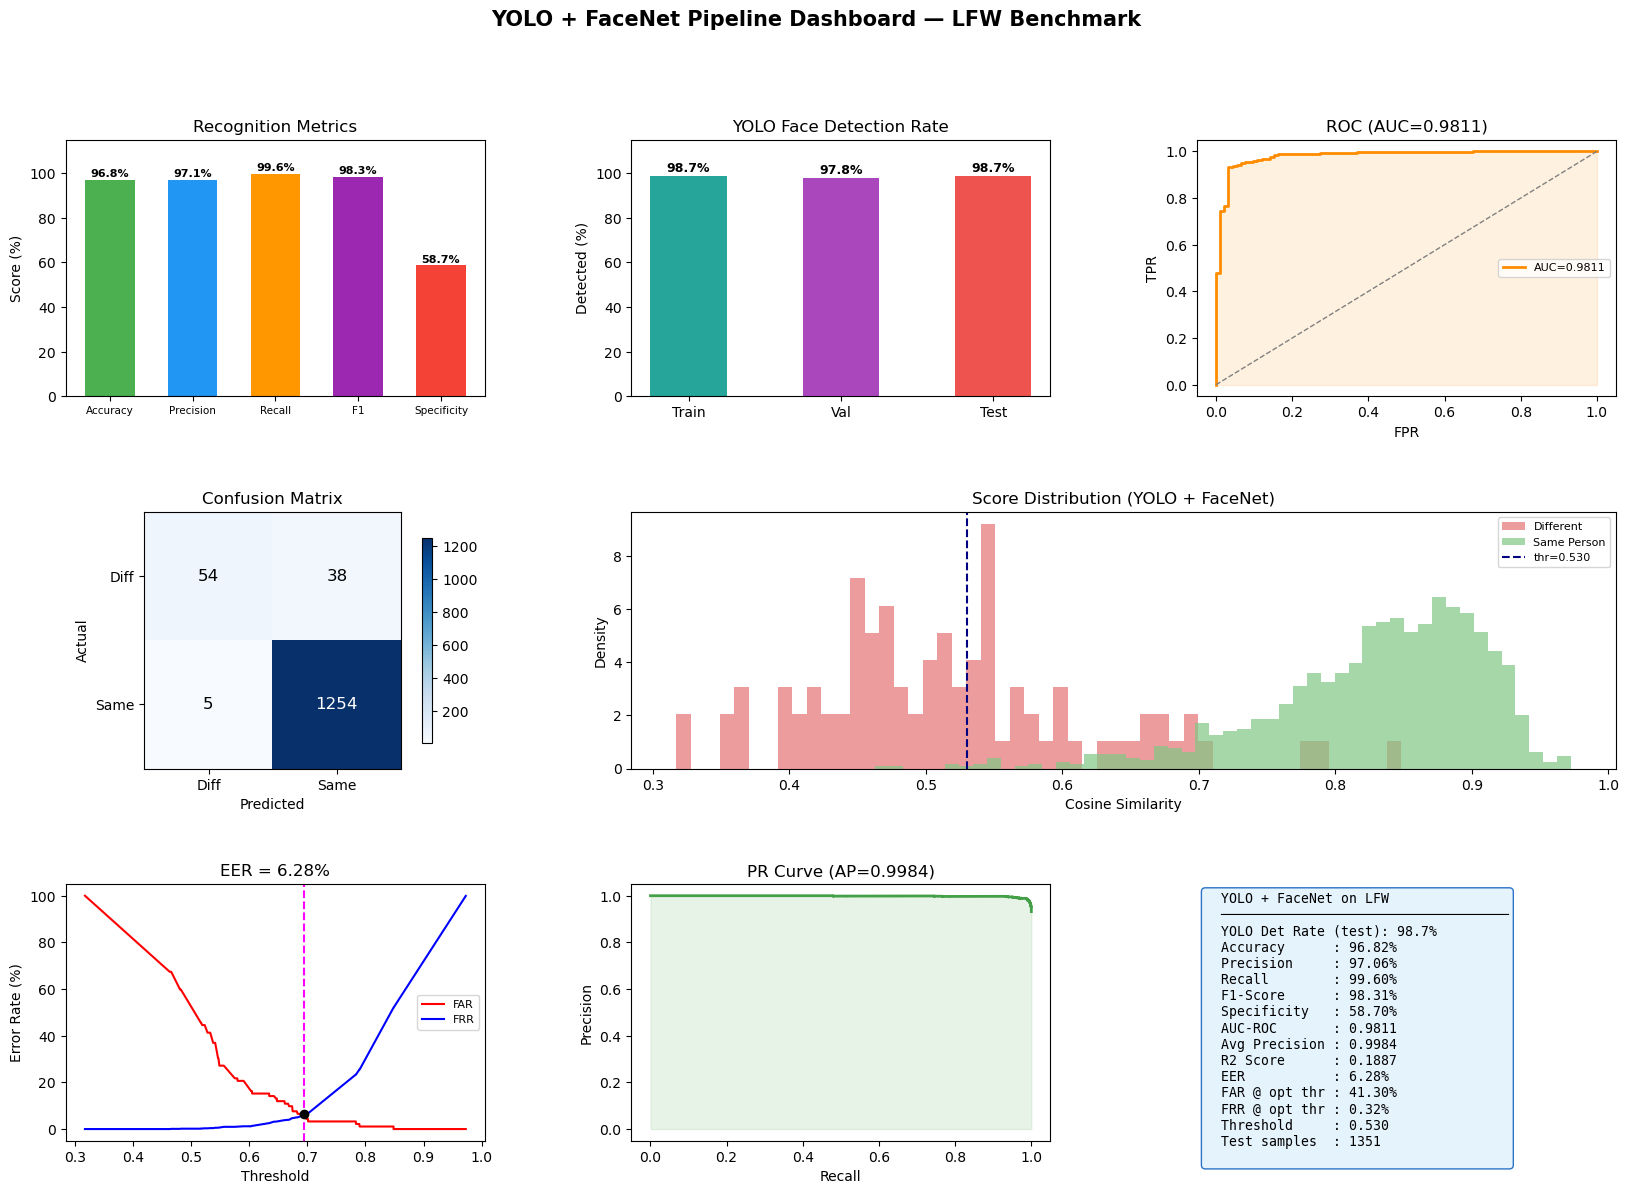

WindowsPath('eval_results/pipeline_lfw_dashboard.png')

In [10]:
def compute_eer(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    return eer, thresholds[idx], fpr, tpr, fnr, thresholds


def plot_dashboard(y_true, y_pred, scores, threshold, det_rates: dict):
    RESULTS_DIR.mkdir(exist_ok=True)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    spec = tn / (tn + fp + 1e-8)

    fpr_r, tpr_r, _ = roc_curve(y_true, scores)
    roc_auc = auc(fpr_r, tpr_r)
    p_pr, r_pr, _   = precision_recall_curve(y_true, scores)
    ap  = average_precision_score(y_true, scores)
    eer, eer_thr, fpr_e, tpr_e, fnr_e, thr_e = compute_eer(y_true, scores)
    r2  = r2_score(y_true, scores)

    dr_tr = det_rates.get("train", 0)
    dr_te = det_rates.get("test",  0)

    fig = plt.figure(figsize=(20, 13))
    fig.suptitle("YOLO + FaceNet Pipeline Dashboard — LFW Benchmark",
                 fontsize=15, fontweight="bold")
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    # 1. Classification metrics
    ax1 = fig.add_subplot(gs[0, 0])
    labels = ["Accuracy", "Precision", "Recall", "F1", "Specificity"]
    vals   = [acc, prec, rec, f1, spec]
    colors = ["#4CAF50", "#2196F3", "#FF9800", "#9C27B0", "#F44336"]
    bars   = ax1.bar(labels, [v*100 for v in vals], color=colors, width=0.6)
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{val*100:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax1.set_ylim(0, 115)
    ax1.set_title("Recognition Metrics")
    ax1.set_ylabel("Score (%)")
    ax1.tick_params(axis="x", labelsize=7.5)

    # 2. YOLO detection rate
    ax2 = fig.add_subplot(gs[0, 1])
    splits = ["Train", "Val", "Test"]
    drs    = [det_rates.get("train", 0), det_rates.get("val", 0), det_rates.get("test", 0)]
    bcol   = ["#26A69A", "#AB47BC", "#EF5350"]
    bars2  = ax2.bar(splits, [d*100 for d in drs], color=bcol, width=0.5)
    for bar, val in zip(bars2, drs):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{val*100:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax2.set_ylim(0, 115)
    ax2.set_title("YOLO Face Detection Rate")
    ax2.set_ylabel("Detected (%)")

    # 3. ROC Curve
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(fpr_r, tpr_r, color="#FF8C00", lw=2, label=f"AUC={roc_auc:.4f}")
    ax3.plot([0, 1], [0, 1], "--", color="grey", lw=1)
    ax3.fill_between(fpr_r, tpr_r, alpha=0.12, color="#FF8C00")
    ax3.set_xlabel("FPR"); ax3.set_ylabel("TPR")
    ax3.set_title(f"ROC (AUC={roc_auc:.4f})")
    ax3.legend(fontsize=8)

    # 4. Confusion Matrix
    ax4 = fig.add_subplot(gs[1, 0])
    cm  = np.array([[tn, fp], [fn, tp]])
    im  = ax4.imshow(cm, cmap="Blues")
    ax4.set_xticks([0, 1]); ax4.set_yticks([0, 1])
    ax4.set_xticklabels(["Diff", "Same"]); ax4.set_yticklabels(["Diff", "Same"])
    ax4.set_xlabel("Predicted"); ax4.set_ylabel("Actual")
    ax4.set_title("Confusion Matrix")
    for r in range(2):
        for c in range(2):
            ax4.text(c, r, str(cm[r, c]), ha="center", va="center",
                     fontsize=12, color="white" if cm[r, c] > cm.max()/2 else "black")
    plt.colorbar(im, ax=ax4, shrink=0.8)

    # 5. Score Distribution
    ax5 = fig.add_subplot(gs[1, 1:3])
    same_s = scores[y_true == 1]
    diff_s = scores[y_true == 0]
    ax5.hist(diff_s, bins=50, color="#E57373", alpha=0.7, density=True, label="Different")
    ax5.hist(same_s, bins=50, color="#81C784", alpha=0.7, density=True, label="Same Person")
    ax5.axvline(threshold, color="navy", linestyle="--", lw=1.5, label=f"thr={threshold:.3f}")
    ax5.set_xlabel("Cosine Similarity"); ax5.set_ylabel("Density")
    ax5.set_title("Score Distribution (YOLO + FaceNet)")
    ax5.legend(fontsize=8)

    # 6. EER Curve
    ax6 = fig.add_subplot(gs[2, 0])
    ax6.plot(thr_e, fpr_e*100, color="red",  label="FAR")
    ax6.plot(thr_e, fnr_e*100, color="blue", label="FRR")
    ax6.axvline(eer_thr, color="magenta", linestyle="--", lw=1.5)
    ax6.scatter([eer_thr], [eer*100], color="black", zorder=5)
    ax6.set_xlabel("Threshold"); ax6.set_ylabel("Error Rate (%)")
    ax6.set_title(f"EER = {eer*100:.2f}%")
    ax6.legend(fontsize=8)

    # 7. PR Curve
    ax7 = fig.add_subplot(gs[2, 1])
    ax7.step(r_pr, p_pr, color="#43A047", where="post", lw=2)
    ax7.fill_between(r_pr, p_pr, alpha=0.12, color="#43A047")
    ax7.set_xlabel("Recall"); ax7.set_ylabel("Precision")
    ax7.set_title(f"PR Curve (AP={ap:.4f})")

    # 8. Summary Box
    ax8 = fig.add_subplot(gs[2, 2])
    ax8.axis("off")
    far_idx = np.argmin(np.abs(thr_e - threshold))
    summary = (
        f"  YOLO + FaceNet on LFW\n"
        f"  {'─'*36}\n"
        f"  YOLO Det Rate (test): {dr_te*100:.1f}%\n"
        f"  Accuracy      : {acc*100:.2f}%\n"
        f"  Precision     : {prec*100:.2f}%\n"
        f"  Recall        : {rec*100:.2f}%\n"
        f"  F1-Score      : {f1*100:.2f}%\n"
        f"  Specificity   : {spec*100:.2f}%\n"
        f"  AUC-ROC       : {roc_auc:.4f}\n"
        f"  Avg Precision : {ap:.4f}\n"
        f"  R2 Score      : {r2:.4f}\n"
        f"  EER           : {eer*100:.2f}%\n"
        f"  FAR @ opt thr : {fpr_e[far_idx]*100:.2f}%\n"
        f"  FRR @ opt thr : {fnr_e[far_idx]*100:.2f}%\n"
        f"  Threshold     : {threshold:.3f}\n"
        f"  Test samples  : {len(y_true)}\n"
    )
    ax8.text(0.02, 0.97, summary, transform=ax8.transAxes,
             fontsize=9.5, verticalalignment="top", fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="#E3F2FD", alpha=0.9, edgecolor="#1565C0"))

    out = RESULTS_DIR / "pipeline_lfw_dashboard.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"\n📊 Dashboard saved: {out}")
    plt.show()
    return out


det_rates = cache.get("yolo_det_rate", {})
plot_dashboard(y_true, y_pred, scores, threshold, det_rates)